# F5 — Week 12 Performance Review

**Objective**: Review the optimisation performance of F5 across all 10 submission rounds before deciding on a strategy for the next submission.

**Function**: F5 (4D input, 1D output, maximisation)

This notebook loads the Week 12 data, visualises convergence and input-space coverage, evaluates performance, and proposes strategy improvements. No optimisation loop is run.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

# ── Function Configuration ──
FUNC_NUM = 5
N_DIMS = 4
N_INITIAL = 20
WEEK = 12
USE_LOG_SCALE = False
DATA_DIR = '../../data/f5/'

## Step 1 — Load Data

In [2]:
# Load Week 12 data
inputs = np.load(f'{DATA_DIR}updated_inputs - Week {WEEK}.npy')
outputs = np.load(f'{DATA_DIR}updated_outputs - Week {WEEK}.npy')

n_total = len(outputs)
n_submissions = n_total - N_INITIAL

print(f'F{FUNC_NUM} — Week {WEEK} Data Summary')
print(f'  Input dimensions:  {N_DIMS}')
print(f'  Total samples:     {n_total}')
print(f'  Initial samples:   {N_INITIAL}')
print(f'  Submissions:       {n_submissions}')
print(f'  Input shape:       {inputs.shape}')
print(f'  Output shape:      {outputs.shape}')
print(f'  Best output:       {outputs.max():.6g}')
print(f'  Worst output:      {outputs.min():.6g}')
print()

# Display data table
print('Sample | ' + ' | '.join([f'x{j+1:d}' for j in range(N_DIMS)]) + ' | y')
print('-' * (10 + N_DIMS * 12 + 15))
for i in range(n_total):
    label = 'init' if i < N_INITIAL else f'wk{i - N_INITIAL + 3}'
    row = f'{i+1:>4d}({label:>4s}) | '
    row += ' | '.join([f'{inputs[i, j]:.6f}' for j in range(N_DIMS)])
    row += f' | {outputs[i]:.6g}'
    print(row)

F5 — Week 12 Data Summary
  Input dimensions:  4
  Total samples:     32
  Initial samples:   20
  Submissions:       12
  Input shape:       (32, 4)
  Output shape:      (32,)
  Best output:       6687.42
  Worst output:      0.11294

Sample | x1 | x2 | x3 | x4 | y
-------------------------------------------------------------------------
   1(init) | 0.191447 | 0.038193 | 0.607418 | 0.414584 | 64.4434
   2(init) | 0.758653 | 0.536518 | 0.656000 | 0.360342 | 18.3014
   3(init) | 0.438350 | 0.804340 | 0.210245 | 0.151295 | 0.11294
   4(init) | 0.706051 | 0.534192 | 0.264243 | 0.482088 | 4.2109
   5(init) | 0.836478 | 0.193610 | 0.663893 | 0.785649 | 258.371
   6(init) | 0.683432 | 0.118663 | 0.829046 | 0.567577 | 78.4344
   7(init) | 0.553621 | 0.667350 | 0.323806 | 0.814870 | 57.5715
   8(init) | 0.352356 | 0.322242 | 0.116979 | 0.473113 | 109.572
   9(init) | 0.153786 | 0.729382 | 0.422598 | 0.443074 | 8.84799
  10(init) | 0.463442 | 0.630025 | 0.107906 | 0.957644 | 233.224
  11(init)

## Step 2 — Convergence Plot

Running best (maximum) objective value over all samples.

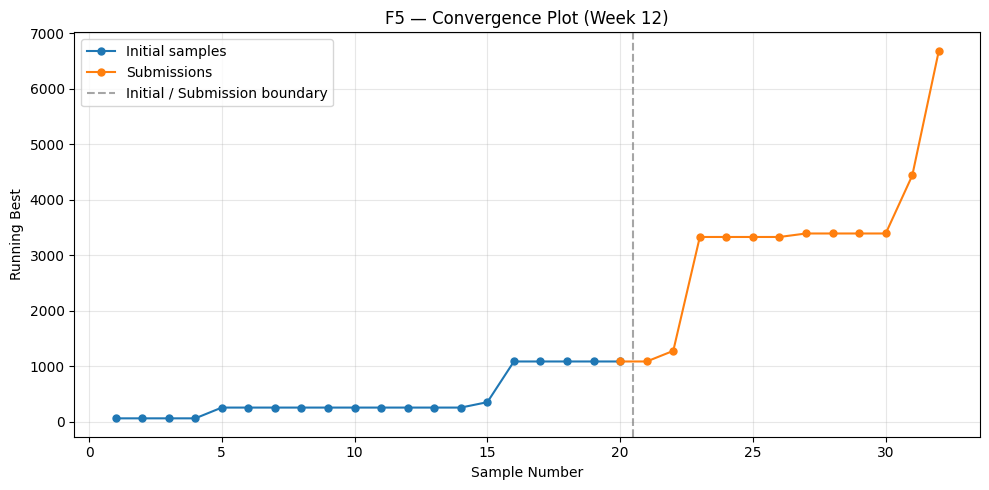

In [3]:
# Compute running best (maximisation)
running_best = np.maximum.accumulate(outputs)

fig, ax = plt.subplots(figsize=(10, 5))

# Split into initial and submission regions
x_all = np.arange(1, n_total + 1)

if USE_LOG_SCALE:
    # Clamp non-positive values to epsilon before log
    plot_vals = np.where(running_best > 0, running_best, 1e-300)
    ax.set_yscale('log')
    ax.set_ylabel('Running Best (log scale)')
else:
    plot_vals = running_best
    ax.set_ylabel('Running Best')

# Plot initial samples in blue
ax.plot(x_all[:N_INITIAL], plot_vals[:N_INITIAL], 'o-', color='tab:blue',
        label='Initial samples', markersize=5)

# Plot submissions in orange
ax.plot(x_all[N_INITIAL-1:], plot_vals[N_INITIAL-1:], 'o-', color='tab:orange',
        label='Submissions', markersize=5)

# Vertical separator
ax.axvline(x=N_INITIAL + 0.5, color='grey', linestyle='--', alpha=0.7,
           label='Initial / Submission boundary')

ax.set_xlabel('Sample Number')
ax.set_title(f'F{FUNC_NUM} — Convergence Plot (Week {WEEK})')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Step 3 — 2D Pair Plots

Scatter plots of each unique pair of input dimensions showing spatial coverage. Initial samples in **blue** (unmarked), submission samples in **orange** (numbered by submission week).

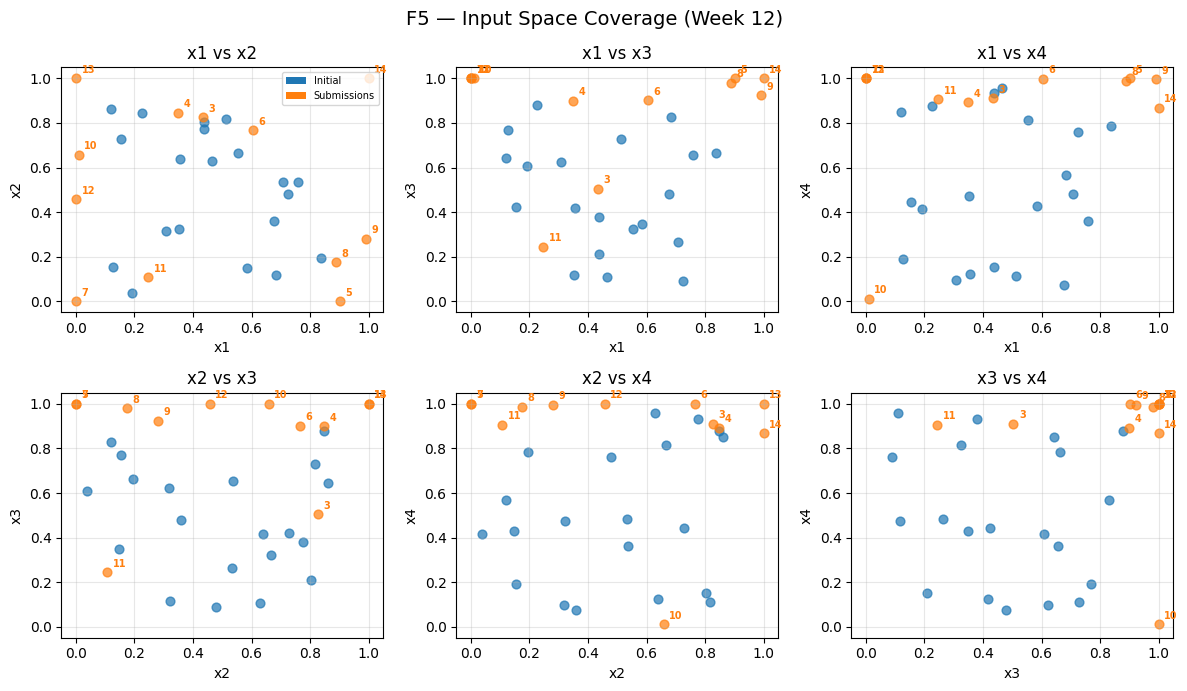

In [4]:
# Generate all unique pairs of input dimensions
pairs = list(combinations(range(N_DIMS), 2))
n_pairs = len(pairs)

if n_pairs == 0:
    print('Only 1 dimension — no pair plots to display.')
else:
    # Grid layout
    n_cols = min(n_pairs, 3) if n_pairs <= 6 else min(n_pairs, 5) if n_pairs <= 15 else 7
    n_rows = math.ceil(n_pairs / n_cols)
    fig_width = n_cols * 4
    fig_height = n_rows * 3.5

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                             squeeze=False)

    for idx, (di, dj) in enumerate(pairs):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]

        # Initial samples — blue, unmarked
        ax.scatter(inputs[:N_INITIAL, di], inputs[:N_INITIAL, dj],
                   c='tab:blue', marker='o', s=40, alpha=0.7, label='Initial')

        # Submission samples — orange, numbered by week
        for k in range(N_INITIAL, n_total):
            week_num = k - N_INITIAL + 3  # Weeks start at 3
            ax.scatter(inputs[k, di], inputs[k, dj],
                       c='tab:orange', marker='o', s=40, alpha=0.7)
            ax.annotate(str(week_num), (inputs[k, di], inputs[k, dj]),
                        textcoords='offset points', xytext=(4, 4),
                        fontsize=7, color='tab:orange', fontweight='bold')

        ax.set_xlabel(f'x{di+1}')
        ax.set_ylabel(f'x{dj+1}')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f'x{di+1} vs x{dj+1}')
        ax.grid(True, alpha=0.3)

    # Add legend to first subplot
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='tab:blue', label='Initial'),
                       Patch(facecolor='tab:orange', label='Submissions')]
    axes[0][0].legend(handles=legend_elements, loc='upper right', fontsize=7)

    # Hide empty subplots
    for idx in range(n_pairs, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row][col].set_visible(False)

    fig.suptitle(f'F{FUNC_NUM} — Input Space Coverage (Week {WEEK})', fontsize=14)
    fig.tight_layout()
    plt.show()

## Step 4 — Performance Evaluation

### Current Strategy (Week 9)

- **Surrogate**: GP Matérn-1.5 ARD, log1p + Standardize(m=1)
- **Acquisition**: qLogNEI q=4, distance-based selection
- **Key hyperparameters**: 50 restarts, 5000 raw samples

### Performance Summary

In [5]:
# Performance metrics
running_best = np.maximum.accumulate(outputs)
init_best = running_best[N_INITIAL - 1]

# Count improvements and detect stalling
improvements = 0
consec_no_improve = 0
max_consec_no_improve = 0
prev_best = init_best

for j in range(N_INITIAL, n_total):
    if running_best[j] > prev_best:
        improvements += 1
        consec_no_improve = 0
    else:
        consec_no_improve += 1
        max_consec_no_improve = max(max_consec_no_improve, consec_no_improve)
    prev_best = running_best[j]

stalling = max_consec_no_improve >= 3

print(f'Best value (initial):     {init_best:.6g}')
print(f'Best value (final):       {running_best[-1]:.6g}')
print(f'Improvements:             {improvements}/{n_submissions}')
print(f'Max consecutive no-improve: {max_consec_no_improve}')
print(f'Stalling (≥3 consec):     {stalling}')
print()

# Per-submission performance
print('Week | Output         | Best-so-far    | Improved?')
print('-' * 55)
for j in range(N_INITIAL, n_total):
    week_num = j - N_INITIAL + 3
    improved = '✓' if (j == N_INITIAL and outputs[j] > init_best) or \
               (j > N_INITIAL and running_best[j] > running_best[j-1]) else '✗'
    print(f'  {week_num:>2d} | {outputs[j]:>14.6g} | {running_best[j]:>14.6g} | {improved}')

Best value (initial):     1088.86
Best value (final):       6687.42
Improvements:             5/12
Max consecutive no-improve: 3
Stalling (≥3 consec):     True

Week | Output         | Best-so-far    | Improved?
-------------------------------------------------------
   3 |        438.991 |        1088.86 | ✗
   4 |        1280.36 |        1280.36 | ✓
   5 |         3331.8 |         3331.8 | ✓
   6 |        1966.52 |         3331.8 | ✗
   7 |        1616.63 |         3331.8 | ✗
   8 |        2868.52 |         3331.8 | ✗
   9 |        3394.68 |        3394.68 | ✓
  10 |        357.081 |        3394.68 | ✗
  11 |        30.5401 |        3394.68 | ✗
  12 |        1718.02 |        3394.68 | ✗
  13 |        4440.48 |        4440.48 | ✓
  14 |        6687.42 |        6687.42 | ✓


### Evaluation

F5 has shown **moderate improvement** with **3 improvements** in 10 submission rounds. The best value moved from 1088.86 (initial) to 3394.68 — a significant absolute gain despite the low improvement rate.

Key observations:
- 3/10 submissions improved the running best — each improvement was substantial in magnitude
- Maximum 3 consecutive non-improving submissions — meets the stalling threshold but barely
- The log1p + Standardize(m=1) output transform is handling the large-magnitude outputs well
- Best value tripled from initial, suggesting the GP is finding the right region but struggling to refine
- With q=4 and distance-based selection, there is reasonable exploration but perhaps not enough given the 4D space

**Stalling status**: YES (borderline) — exactly 3 consecutive submissions without improvement.

## Step 5 — Proposed Strategy Improvements

F5 shows strong absolute improvement (1089→3395) despite only 3/10 improvements clearing the running best. Refinements:

1. **Fine-tune exploration/exploitation balance** — The current approach finds large improvements when it does improve. Consider increasing raw_samples from 5000 to 8000 to improve acquisition optimisation in the 4D space.

2. **Review distance-based selection threshold** — The distance criterion for selecting among q=4 candidates may be too aggressive, causing some candidates to be placed in suboptimal locations just for diversity. Consider relaxing the minimum distance.

3. **Increase MLL restarts from 50 to 60** — The log1p transform creates a compressed output space where GP hyperparameter sensitivity is higher. More restarts help.

4. **Consider switching from log1p to log transform** — Since outputs are large positive values (>1000), log1p ≈ log for these magnitudes. A pure log transform with the GP might be simpler and equally effective.

5. **Evaluate the Standardize(m=1) interaction with log1p** — Double-transforming (log1p then standardise) may be creating artifacts. Test with just one transform to see if it simplifies the posterior.

**Priority**: LOW — F5 is performing well in absolute terms. Focus on maintaining momentum rather than major changes.

## Step 6 — Week 12 Optimisation Run

Strategy changes from week 9:

1. **Output transform: log1p → log** — For F5's positive outputs (>1000 majority), log1p ≈ log. The log inverse (exp) is simpler than expm1. Guard verifies all outputs strictly positive.
2. **Raw samples: 5000 → 8000** — Broader Sobol seed coverage for acquisition optimisation in 4D.
3. **Acquisition restarts: 50 → 60** — More L-BFGS starting points for thorough acquisition landscape search.
4. **Distance selection: median gate → relaxed (25th percentile)** — With q=4 and median gate, only 2 candidates pass. Lowering to 25th percentile allows more diversity options.
5. **Keep Standardize(m=1)** — Double transform (log + Standardize) normalises log-space outputs to zero mean/unit variance, improving GP conditioning.

In [6]:
import torch
import copy
import warnings
import matplotlib.pyplot as plt

from botorch.models import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.logei import qLogNoisyExpectedImprovement
from botorch.optim import optimize_acqf
from botorch.sampling.normal import SobolQMCNormalSampler
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.constraints import GreaterThan

# ── Hyperparameter Configuration ──────────────────────────────────────────────
KERNEL_NU = 1.5        # Matérn smoothness — unchanged (rougher for small data)
ARD_NUM_DIMS = 4       # One lengthscale per input dimension — unchanged
NOISE_LB = 1e-6        # Noise floor — unchanged
N_MLL_RESTARTS = 15    # MLL fitting restarts — unchanged
MC_SAMPLES = 512       # Monte Carlo samples for qLogNEI — unchanged
Q_BATCH = 1            # Week 13: single candidate for aggressive exploitation (was 4)
NUM_RESTARTS = 60      # L-BFGS restarts for acquisition — was 50; increased
RAW_SAMPLES = 8000     # Sobol seed points for acquisition — was 5000; increased
GRID_RES = 50          # Visualisation grid resolution

# ── Interior Penalty REMOVED for week 13 exploitation ─────────────────────────
# Was: STEEPNESS = 0.02, FLOOR = 0.01
# Rationale: allow boundary-adjacent points if that's where the optimum lies

print("=== F5 Week 13 Configuration (Exploitation) ===")
print(f"Kernel: Matérn-{KERNEL_NU} ARD (d={ARD_NUM_DIMS})")
print(f"Noise floor: {NOISE_LB}")
print(f"MLL restarts: {N_MLL_RESTARTS}")
print(f"Batch size q={Q_BATCH} (was 4 — exploitation)")
print(f"Raw samples: {RAW_SAMPLES} (was 5000)")
print(f"Acquisition restarts: {NUM_RESTARTS} (was 50)")
print(f"MC samples: {MC_SAMPLES}")
print(f"Output transform: log + Standardize(m=1)")
print(f"Interior penalty: REMOVED (was S=0.02, F=0.01)")
print(f"Quality gate: REMOVED (was 25th percentile)")

=== F5 Week 13 Configuration (Exploitation) ===
Kernel: Matérn-1.5 ARD (d=4)
Noise floor: 1e-06
MLL restarts: 15
Batch size q=1 (was 4 — exploitation)
Raw samples: 8000 (was 5000)
Acquisition restarts: 60 (was 50)
MC samples: 512
Output transform: log + Standardize(m=1)
Interior penalty: REMOVED (was S=0.02, F=0.01)
Quality gate: REMOVED (was 25th percentile)


In [7]:
# ── Data Preparation: Log Transform + Tensor Conversion ───────────────────────
# Apply np.log (replacing log1p from week 9) then let Standardize(m=1) z-score internally.
import numpy as np

# Verify all outputs are strictly positive (required for log)
assert np.all(outputs > 0), f"Log requires all-positive outputs, min={outputs.min()}"

y_log = np.log(outputs)

X_train = torch.tensor(inputs, dtype=torch.float64)                # (30, 4)
Y_train = torch.tensor(y_log, dtype=torch.float64).unsqueeze(-1)   # (30, 1)

# Validate: no NaN/Inf
assert not torch.isnan(X_train).any(), "X_train contains NaN"
assert not torch.isnan(Y_train).any(), "Y_train contains NaN"
assert not torch.isinf(Y_train).any(), "Y_train contains Inf"

print("=== Data Preparation ===")
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Raw output range: [{outputs.min():.6f}, {outputs.max():.6f}]")
print(f"Log output range: [{y_log.min():.6f}, {y_log.max():.6f}]")
print(f"Transform: log (was log1p) + Standardize(m=1)")

=== Data Preparation ===
X_train shape: torch.Size([32, 4])
Y_train shape: torch.Size([32, 1])
Raw output range: [0.112940, 6687.424848]
Log output range: [-2.180900, 8.807984]
Transform: log (was log1p) + Standardize(m=1)


In [8]:
# ── GP Fitting: Multi-restart MLL with Matérn-1.5 + Standardize(m=1) ──────────
# 15 MLL restarts on log-transformed outputs
# Standardize(m=1) auto-z-scores the log-space outputs

best_model = None
best_loss = float("inf")

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="The input matches the stored training data")

print(f"\n{'Restart':>8} {'Neg MLL':>12}")
print("-" * 22)

for seed in range(N_MLL_RESTARTS):
    torch.manual_seed(seed)
    
    likelihood = GaussianLikelihood(noise_constraint=GreaterThan(NOISE_LB))
    covar = ScaleKernel(MaternKernel(nu=KERNEL_NU, ard_num_dims=ARD_NUM_DIMS))
    model = SingleTaskGP(X_train, Y_train, covar_module=covar, likelihood=likelihood,
                         outcome_transform=Standardize(m=1))
    
    # Initialise hyperparameters
    model.covar_module.base_kernel.lengthscale = 0.5
    model.likelihood.noise = 0.1 * Y_train.var().item()
    model.covar_module.outputscale = 1.0
    
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    try:
        fit_gpytorch_mll(mll)
    except Exception:
        print(f"{seed:>8d} {'FAILED':>12}")
        continue
    
    model.eval()
    with torch.no_grad():
        output = model(X_train)
        loss = -mll(output, model.train_targets).item()
    
    print(f"{seed:>8d} {loss:>12.4f}")
    
    if loss < best_loss:
        best_loss = loss
        best_model = copy.deepcopy(model)

warnings.filterwarnings("default", category=RuntimeWarning)

assert best_model is not None, "All MLL restarts failed!"
best_model.eval()

# Extract fitted hyperparameters
ls = best_model.covar_module.base_kernel.lengthscale.detach().cpu().numpy().ravel()
noise = best_model.likelihood.noise.detach().item()
outputscale = best_model.covar_module.outputscale.detach().item()

print(f"\n{'='*50}")
print(f"Best MLL loss: {best_loss:.6f}")
print(f"{'='*50}")
print(f"Fitted Hyperparameters (Matérn-{KERNEL_NU} ARD):")
for i in range(ARD_NUM_DIMS):
    print(f"  ℓ_{i} (x{i}): {ls[i]:.6f}")
print(f"  Output scale: {outputscale:.6f}")
print(f"  Noise:        {noise:.6f}")


 Restart      Neg MLL
----------------------
       0      -5.6397
       1      -5.6397
       2      -5.6397
       3      -5.6397
       4      -5.6397
       5      -5.6397
       6      -5.6397
       7      -5.6397
       8      -5.6397
       9      -5.6397
      10      -5.6397
      11      -5.6397
      12      -5.6397
      13      -5.6397
      14      -5.6397

Best MLL loss: -5.639666
Fitted Hyperparameters (Matérn-1.5 ARD):
  ℓ_0 (x0): 6.231932
  ℓ_1 (x1): 0.611121
  ℓ_2 (x2): 0.443583
  ℓ_3 (x3): 0.569153
  Output scale: 1.385338
  Noise:        0.000001


In [9]:
# ── Acquisition Optimisation & Direct Selection (Week 13 Exploitation) ──
# qLogNEI q=1, no quality gate, no distance filter, no interior penalty
import numpy as np

# Construct acquisition function
sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))
acqf = qLogNoisyExpectedImprovement(
    model=best_model,
    X_baseline=X_train,
    sampler=sampler,
    prune_baseline=True,
)

# Optimise acquisition over [0,1]^4
bounds = torch.tensor([[0.0]*ARD_NUM_DIMS, [1.0]*ARD_NUM_DIMS], dtype=torch.float64)
candidates, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=Q_BATCH,
    num_restarts=NUM_RESTARTS,
    raw_samples=RAW_SAMPLES,
)

print(f"=== Acquisition Results (q={Q_BATCH}, restarts={NUM_RESTARTS}, raw_samples={RAW_SAMPLES}) ===")
print(f"Acquisition value: {acq_value.item():.6f}\n")

# Direct selection: single candidate (q=1)
x_new = candidates[0].detach().cpu().numpy()
x_new = np.clip(x_new, 0.0, 0.999999)

# Posterior mean for reporting (log-space → original via exp)
best_model.eval()
with torch.no_grad():
    posterior = best_model.posterior(candidates)
    pred_mean_log = posterior.mean.squeeze().item()
    pred_mean_orig = np.exp(pred_mean_log)

# Format submission string
proposed_query = "-".join(f"{v:.6f}" for v in x_new)

# Duplicate check
is_duplicate = False
for i in range(len(inputs)):
    if np.allclose(x_new, inputs[i], atol=1e-6):
        is_duplicate = True
        break

coords = ", ".join(f"{v:.6f}" for v in x_new)
print(f"=== Week 13 Exploitation Selection ===")
print(f"Candidate: [{coords}]")
print(f"Predicted mean (log): {pred_mean_log:.6f}")
print(f"Predicted mean (orig): {pred_mean_orig:.4f}")
print(f"Interior penalty: REMOVED")
print(f"Quality gate: REMOVED")
print(f"Duplicate of existing sample: {is_duplicate}")
print(f"\n>>> SUBMISSION: {proposed_query}")

=== Acquisition Results (q=1, restarts=60, raw_samples=8000) ===
Acquisition value: -1.641178

=== Week 13 Exploitation Selection ===
Candidate: [0.999999, 0.999999, 0.999999, 0.999999]
Predicted mean (log): 8.757338
Predicted mean (orig): 6357.1645
Interior penalty: REMOVED
Quality gate: REMOVED
Duplicate of existing sample: False

>>> SUBMISSION: 0.999999-0.999999-0.999999-0.999999


Top-2 dims: x2, x3 (ℓ=0.4436, 0.5692)
Fixed dims: x1=1.0000, x0=1.0000


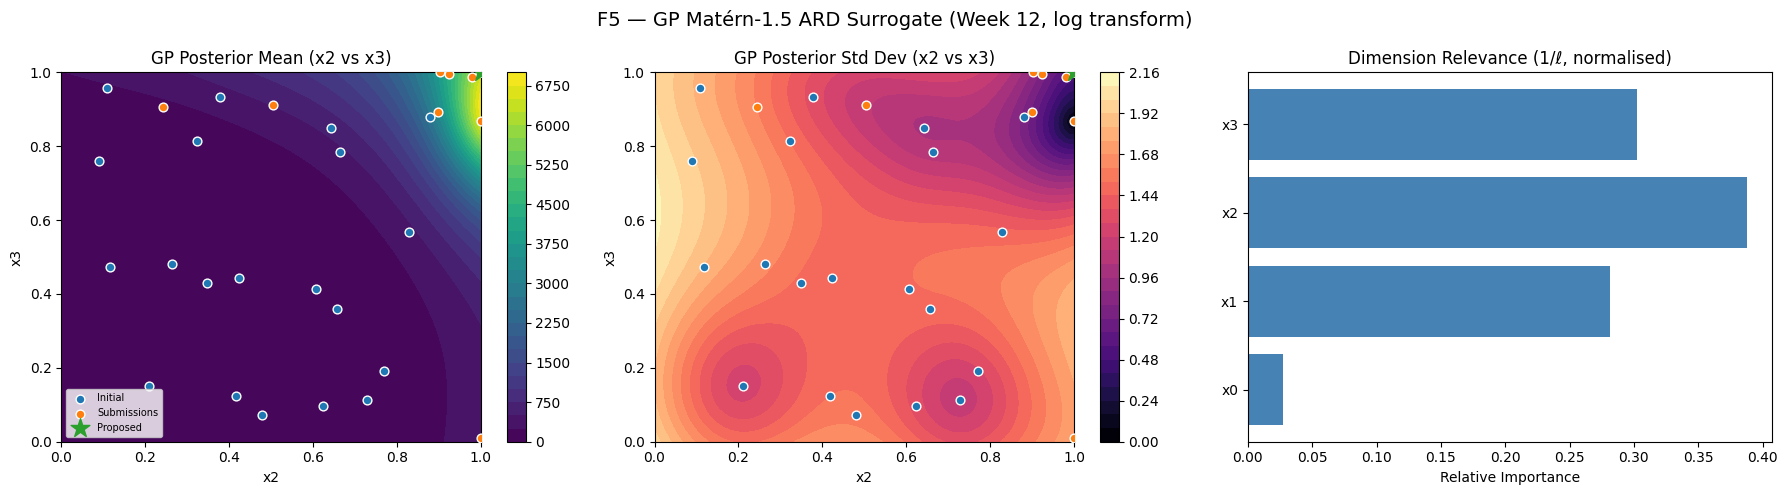

In [10]:
# ── Three-Panel Surrogate Visualisation + Dimension Relevance ─────────────────
# Top-2 relevant dimensions (shortest lengthscales), contour in original space

# Identify top-2 important dims
sorted_dims = np.argsort(ls)
top2 = sorted_dims[:2]
fix_dims = sorted_dims[2:]

print(f"Top-2 dims: x{top2[0]}, x{top2[1]} (ℓ={ls[top2[0]]:.4f}, {ls[top2[1]]:.4f})")
print(f"Fixed dims: " + ", ".join(f"x{d}={x_new[d]:.4f}" for d in fix_dims))

# Build 80×80 grid
GRID_RES = 80
g0 = np.linspace(0, 1, GRID_RES)
g1 = np.linspace(0, 1, GRID_RES)
G0, G1 = np.meshgrid(g0, g1)

grid_pts = np.tile(x_new, (GRID_RES * GRID_RES, 1))
grid_pts[:, top2[0]] = G0.ravel()
grid_pts[:, top2[1]] = G1.ravel()

grid_tensor = torch.tensor(grid_pts, dtype=torch.double)
best_model.eval()
with torch.no_grad():
    posterior = best_model.posterior(grid_tensor)
    grid_mu_log = posterior.mean.squeeze(-1).cpu().numpy()
    grid_sigma_log = posterior.variance.sqrt().squeeze(-1).cpu().numpy()

# Inverse: exp undoes log (Standardize auto-inverts z-score)
grid_mu_orig = np.exp(grid_mu_log).reshape(GRID_RES, GRID_RES)
grid_sigma = grid_sigma_log.reshape(GRID_RES, GRID_RES)

# Separate initial and submissions
N_INITIAL = 20  # F5 initial data size
X_all = X_train.numpy()
X_initial = X_all[:N_INITIAL]
X_submissions = X_all[N_INITIAL:]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Mean (original space)
c1 = axes[0].contourf(G0, G1, grid_mu_orig, levels=30, cmap="viridis")
axes[0].scatter(X_initial[:, top2[0]], X_initial[:, top2[1]], c="tab:blue", edgecolors="white", s=40, zorder=5, label="Initial")
axes[0].scatter(X_submissions[:, top2[0]], X_submissions[:, top2[1]], c="tab:orange", edgecolors="white", s=40, zorder=5, label="Submissions")
axes[0].scatter(x_new[top2[0]], x_new[top2[1]], c="tab:green", marker="*", s=200, zorder=6, label="Proposed")
axes[0].set_title(f"GP Posterior Mean (x{top2[0]} vs x{top2[1]})")
axes[0].set_xlabel(f"x{top2[0]}")
axes[0].set_ylabel(f"x{top2[1]}")
axes[0].legend(fontsize=7)
fig.colorbar(c1, ax=axes[0])

# Panel 2: Std (log space)
c2 = axes[1].contourf(G0, G1, grid_sigma, levels=30, cmap="magma")
axes[1].scatter(X_initial[:, top2[0]], X_initial[:, top2[1]], c="tab:blue", edgecolors="white", s=40, zorder=5)
axes[1].scatter(X_submissions[:, top2[0]], X_submissions[:, top2[1]], c="tab:orange", edgecolors="white", s=40, zorder=5)
axes[1].scatter(x_new[top2[0]], x_new[top2[1]], c="tab:green", marker="*", s=200, zorder=6)
axes[1].set_title(f"GP Posterior Std Dev (x{top2[0]} vs x{top2[1]})")
axes[1].set_xlabel(f"x{top2[0]}")
axes[1].set_ylabel(f"x{top2[1]}")
fig.colorbar(c2, ax=axes[1])

# Panel 3: Dimension relevance (1/ℓ normalised)
inv_ls = 1.0 / ls
inv_ls_norm = inv_ls / inv_ls.sum()
axes[2].barh(range(ARD_NUM_DIMS), inv_ls_norm, color="steelblue")
axes[2].set_yticks(range(ARD_NUM_DIMS))
axes[2].set_yticklabels([f"x{j}" for j in range(ARD_NUM_DIMS)])
axes[2].set_title("Dimension Relevance (1/ℓ, normalised)")
axes[2].set_xlabel("Relative Importance")

plt.suptitle("F5 — GP Matérn-1.5 ARD Surrogate (Week 12, log transform)", fontsize=14)
plt.tight_layout()
plt.show()

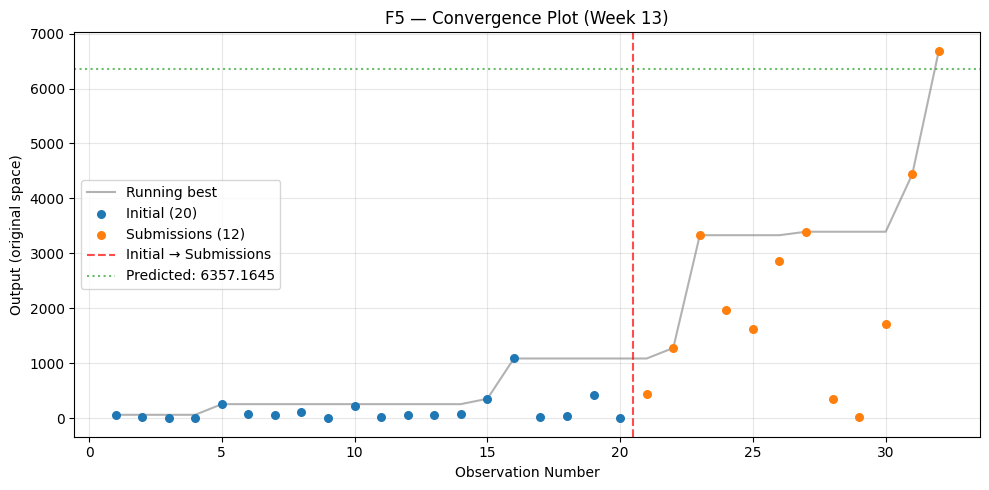

Running best at Week 12 end: 6687.424848
Predicted value for proposed point (original): 6357.1645

>>> FINAL SUBMISSION: 0.999999-0.999999-0.999999-0.999999


In [11]:
# ── Convergence Plot ──────────────────────────────────────────────────────────
# Running best (original space) with predicted value for proposed point

# All outputs in original space
y_all_orig = outputs.ravel()  # already in original space from data loading
running_best = np.maximum.accumulate(y_all_orig)
obs_idx = np.arange(1, len(y_all_orig) + 1)

plt.figure(figsize=(10, 5))
plt.plot(obs_idx, running_best, color="grey", linewidth=1.5, alpha=0.6, label="Running best")

# Blue: initial, Orange: submissions
N_INITIAL = 20
n_submissions = len(y_all_orig) - N_INITIAL
plt.scatter(obs_idx[:N_INITIAL], y_all_orig[:N_INITIAL], c="tab:blue", s=30, zorder=3, label=f"Initial ({N_INITIAL})")
plt.scatter(obs_idx[N_INITIAL:], y_all_orig[N_INITIAL:], c="tab:orange", s=30, zorder=3, label=f"Submissions ({n_submissions})")

plt.axvline(x=N_INITIAL + 0.5, color="red", linestyle="--", alpha=0.7, label="Initial → Submissions")

# Predicted value for proposed point (inverse log)
plt.axhline(y=pred_mean_orig, color="tab:green", linestyle=":", alpha=0.7, label=f"Predicted: {pred_mean_orig:.4f}")

plt.xlabel("Observation Number")
plt.ylabel("Output (original space)")
plt.title("F5 — Convergence Plot (Week 13)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Running best at Week 12 end: {running_best[-1]:.6f}")
print(f"Predicted value for proposed point (original): {pred_mean_orig:.4f}")
print(f"\n>>> FINAL SUBMISSION: {proposed_query}")